In [1]:
!pip install pandas numpy matplotlib seaborn ta


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Import Library/Packages**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.max_open_warning'] = 0

# **PERTANYAAN BISNIS**

Bagaimana investor pemula yang menggunakan platform *Anti FOMO Stock Mentor* dapat menentukan sinyal *buy*, *sell*, atau *hold* dengan menggunakan kondisi teknikal saham IDX yang didasarkan pada indikator RSI dan tren *Moving Average* dari September 2022 hingga Oktober 2023?

# **DATA WRANGLING**

## **Gathering Data**

Langkah pertama dalam proses analisis adalah dengan memuat dataset ke dalam environment notebook. Pada tahap ini, akan dilakukan eksplorasi awal untuk memahami struktur data serta fitur (kolom) yang tersedia.

Dataset yang digunakan adalah **IDX Stock Summary 2020-2024**, yang berisi data historis
perdagangan saham di Bursa Efek Indonesia (BEI). Data difokuskan secara spesifik pada rentang waktu September 2022 hingga Oktober 2023, karena ini adalah periode pasca pandemi Covid-19 dan menunjukkan pergerakan pasar yang lebih stabil, serta mencakup periode sekitar satu tahun, sehingga memadai untuk uji akurasi  sinyal *buy*, *sell*, atau *hold* melalui indikator RSI dan *Moving Average*.

Dataset ini terdiri dari ribuan baris data transaksi saham dengan berbagai atribut yang mencerminkan aktivitas perdagangan harian.

**Dataset ini memiliki beberapa kelompok fitur utama sebagai berikut:**

**Informasi Identitas Saham**
- Stock Code: Kode unik saham (contoh: BBCA, AALI). Digunakan sebagai identitas utama setiap saham.
- Company Name: Nama perusahaan penerbit saham. Memberikan informasi tambahan terkait entitas perusahaan.
- Remarks: Keterangan tambahan terkait saham. Biasanya tidak digunakan dalam analisis utama.

**Informasi Harga Saham**
- `Previous`: Harga penutupan pada hari sebelumnya
- `Open Price`: Harga pembukaan saham
- `High`: Harga tertinggi dalam satu hari
- `Low`: Harga terendah dalam satu hari
- `Close`: Harga penutupan saham

Kelompok ini merupakan fitur paling penting dalam analisis karena mencerminkan pergerakan harga saham.

**Informasi Waktu (Time Series)**
- `Last Trading Date`: Tanggal terakhir transaksi saham
- `First Trade`: Harga transaksi pertama dalam hari tersebut

Kolom ini sangat penting karena menunjukkan bahwa data bersifat time series
digunakan untuk analisis tren dan prediksi

**Aktivitas Perdagangan**
- `Volume`: Jumlah saham yang diperdagangkan
- `Value`: Nilai total transaksi
- `Frequency`: Frekuensi transaksi

Digunakan untuk melihat seberapa aktif suatu saham diperdagangkan
hubungan antara volume dan pergerakan harga.

**Informasi Bid & Offer**
- `Bid`: Harga permintaan beli tertinggi
- `Offer`: Harga penawaran jual terendah
- `Bid Volume`: Volume permintaan beli
- `Offer Volume`: Volume penawaran jual

Memberikan gambaran kondisi pasar tekanan beli vs jual

**Kepemilikan & Indeks**
- `Listed Shares`: Jumlah saham terdaftar
- `Tradeable Shares`: Saham yang bisa diperdagangkan
- `Weight For Index`: Bobot saham dalam indeks

Digunakan untuk analisis lanjutan terkait kapitalisasi pasar.

**Aktivitas Investor**
- `Foreign Buy`: Jumlah pembelian oleh investor asing
- `Foreign Sell`: Jumlah penjualan oleh investor asing

Bisa digunakan untuk melihat pengaruh investor asing terhadap harga saham.

**Transaksi Non-Reguler**
- `Non Regular Volume`
- `Non Regular Value`
- `Non Regular Frequency`

Transaksi di luar pasar reguler (opsional untuk analisis lanjutan).

In [3]:
import csv
# Untuk Load Dataset
df = pd.read_csv('IDX Stock Summary 2020-2024.csv', encoding='latin1', on_bad_lines='skip', quoting=csv.QUOTE_NONE)

# Untuk Cek 5 Baris Utama
df.head()

,"""No""","""Stock Code""","""Company Name""","""Remarks""","""Previous""","""Open Price""","""Last Trading Date""","""First Trade""","""High""","""Low""","""Close""","""Change""","""Volume""","""Value""","""Frequency""","""Index Individual""","""Offer""","""Offer Volume""","""Bid""","""Bid Volume""","""Listed Shares""","""Tradeble Shares""","""Weight For Index""","""Foreign Sell""","""Foreign Buy""","""Non Regular Volume""","""Non Regular Value""","""Non Regular Frequency"""
0,1,"""AALI""","""Astra Agro Lestari Tbk.""","""--S1K--1""",14575,0,"""02 Jan 2020""",0,14650,14025,14025,-550,799000,11451335000,888,1139.40,14200,12200,14025.00,49900,1924688333.00,1924688333.00,1924688333.00,106300,253800,0.00,0.00,0
1,2,"""ABBA""","""Mahaka Media Tbk.""","""--U9---2""",106,0,"""02 Jan 2020""",0,108,105,105,-1,6340800,671926200,624,184.20,106,201200,105.00,786900,2755125000.00,2755125000.00,2755125000.00,21600,0,0.00,0.00,0
2,3,"""ABDA""","""Asuransi Bina Dana Arta Tbk.""","""--U8---2""",6975,0,"""02 Jan 2020""",0,7075,6925,6925,-50,1700,12012500,6,1581.00,6775,100,5600.00,100,620806680.00,620806680.00,620806680.00,1600,0,0.00,0.00,0
3,4,"""ABMM""","""ABM Investama Tbk.""","""--U9---1""",1530,0,"""02 Jan 2020""",0,0,0,1530,0,0,0,0,40.80,1525,2400,1205.00,500,2753165000.00,2753165000.00,2753165000.00,0,0,0.00,0.00,0
4,5,"""ACES""","""Ace Hardware Indonesia Tbk.""","""--S9KB-1""",1495,0,"""02 Jan 2020""",0,1535,1500,1510,15,13727900,20813082500,3295,1841.50,1515,38200,1510.00,572700,17150000000.00,17150000000.00,17150000000.00,7584400,5264200,51000005.00,77367007600.00,3


In [4]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 830712
Jumlah kolom: 28


### **Kesimpulan:**

Dataset berisi 830.712 baris dan 28 kolom. Pada saat ini data masih dalam kondisi yang mentah dan memerlukan preposesing yang kompleks agar dapat digunakan secara optimal.

## **Assessing Data**

Setelah data berhasil dikumpulkan, langkah selanjutnya adalah melakukan penilaian (assessing) untuk mengidentifikasi potensi permasalahan kualitas dalam dataset. Tahap ini penting dilakukan sebelum proses pembersihan data (data cleaning) agar kita mengetahui apa saja yang perlu diperbaiki.

Pemeriksaan ini mencakup beberapa aspek utama sebagai berikut:
1. **Pemeriksaan Tipe Data.** Kita perlu memastikan bahwa setiap kolom memiliki tipe data yang sesuai dengan isinya. Sebagai contoh, kolom tanggal seharusnya bertipe datetime, bukan object, agar dapat digunakan dalam analisis time series.
2. **Pemeriksaan Missing Values.** Dilakukan untuk mengecek apakah terdapat nilai yang hilang (null/NaN) pada setiap kolom. Nilai yang kosong dapat memengaruhi hasil analisis serta menurunkan performa model machine learning.
3. **Pemeriksaan Data Duplikat.** Bertujuan untuk mengidentifikasi apakah terdapat baris data yang sama persis (duplikat). Data duplikat dapat menyebabkan bias dan membuat hasil analisis menjadi tidak akurat.
4. **Ringkasan Parameter Statistik.** Melihat distribusi data melalui statistik deskriptif seperti mean, median, minimum, maximum, dan kuartil. Hal ini membantu dalam mendeteksi adanya anomali atau nilai ekstrem (outliers).

In [5]:
#Pemeriksaan Struktur dan Tipe Data
print("Jumlah baris dan kolom:", df.shape)
df.info()

Jumlah baris dan kolom: (830712, 28)
<class 'pandas.DataFrame'>
RangeIndex: 830712 entries, 0 to 830711
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   "No"                     830712 non-null  int64  
 1   "Stock Code"             830712 non-null  str    
 2   "Company Name"           830712 non-null  str    
 3   "Remarks"                830712 non-null  str    
 4   "Previous"               830712 non-null  int64  
 5   "Open Price"             830712 non-null  int64  
 6   "Last Trading Date"      830712 non-null  str    
 7   "First Trade"            830712 non-null  int64  
 8   "High"                   830712 non-null  int64  
 9   "Low"                    830712 non-null  int64  
 10  "Close"                  830712 non-null  int64  
 11  "Change"                 830712 non-null  int64  
 12  "Volume"                 830712 non-null  int64  
 13  "Value"                  830712 n

**Insight:**
- Dataset memiliki **830.712 baris** dan **28 kolom** dengan penggunaan memori sebesar 237.6 MB
- Tipe data terdiri dari:
  - `int64` (17 kolom), terdiri dari kolom harga, volume, dan aktivitas perdagangan
  - `float64` (7 kolom), terdiri dari kolom indeks, bid, listed shares, dll
  - `str` (4 kolom), terdiri dari `Stock Code`, `Company Name`, `Remarks`, dan `Last Trading Date`
- Ditemukan **inkonsistensi tipe data** yang perlu diperbaiki:
  - Kolom `Last Trading Date` masih bertipe `str`, padahal seharusnya `datetime`
    agar dapat digunakan sebagai sumbu waktu dalam analisis time series RSI dan Moving Average
- Kolom harga seperti `Close`, `High`, `Low`, `Open Price` sudah bertipe `int64`
  dan siap digunakan untuk perhitungan indikator teknikal
- Kolom `No`, `Company Name`, `Remarks`, dan kolom Non-Regular tidak relevan
  untuk analisis teknikal, sehingga akan dihapus pada tahap cleaning

In [6]:
#Pemeriksaan Missing Values
df.isnull().sum()

"No"                       0
"Stock Code"               0
"Company Name"             0
"Remarks"                  0
"Previous"                 0
"Open Price"               0
"Last Trading Date"        0
"First Trade"              0
"High"                     0
"Low"                      0
"Close"                    0
"Change"                   0
"Volume"                   0
"Value"                    0
"Frequency"                0
"Index Individual"         0
"Offer"                    0
"Offer Volume"             0
"Bid"                      0
"Bid Volume"               0
"Listed Shares"            0
"Tradeble Shares"          0
"Weight For Index"         0
"Foreign Sell"             0
"Foreign Buy"              0
"Non Regular Volume"       0
"Non Regular Value"        0
"Non Regular Frequency"    0
dtype: int64

**Insight**
- Tidak terdapat missing values pada seluruh kolom
- Dataset memiliki kelengkapan data yang sangat baik
- Tidak perlu penanganan missing value pada tahap cleaning
- Ini mempermudah proses modeling karena tidak perlu imputasi

In [7]:
# Untuk Cek Duplikasi
print('Jumlah duplikasi:', df.duplicated().sum())

Jumlah duplikasi: 54349


**Insight**
- Ditemukan 54.349 data duplikat

Jika tidak dihapus, duplikasi ini dapat menyebabkan:
- Perhitungan RSI dan Moving Average menjadi tidak akurat karena data harga   yang sama dihitung lebih dari satu kali
- Analisis tren harga menjadi bias karena ada pengulangan nilai pada tanggal tertentu

In [8]:
#Menampilkan Data Duplikat
df[df.duplicated()]

,"""No""","""Stock Code""","""Company Name""","""Remarks""","""Previous""","""Open Price""","""Last Trading Date""","""First Trade""","""High""","""Low""","""Close""","""Change""","""Volume""","""Value""","""Frequency""","""Index Individual""","""Offer""","""Offer Volume""","""Bid""","""Bid Volume""","""Listed Shares""","""Tradeble Shares""","""Weight For Index""","""Foreign Sell""","""Foreign Buy""","""Non Regular Volume""","""Non Regular Value""","""Non Regular Frequency"""
7398,1,"""AALI""","""Astra Agro Lestari Tbk.""","""--S1K--1""",12525,0,"""16 Jan 2020""",0,12950,12525,12675,150,1389300,17735872500,1548,1029.70,12675,20000,12650.00,56100,1924688333.00,1924688333.00,1924688333.00,175300,318000,66.00,834900.00,1
7399,2,"""ABBA""","""Mahaka Media Tbk.""","""--U9---2""",100,0,"""16 Jan 2020""",0,100,95,98,-2,10808300,1051748300,816,171.90,99,1075200,98.00,759200,2755125000.00,2755125000.00,2755125000.00,121300,0,0.00,0.00,0
7400,3,"""ABDA""","""Asuransi Bina Dana Arta Tbk.""","""--U8---2""",6800,0,"""16 Jan 2020""",0,0,0,6800,0,0,0,0,1552.40,6800,200,5450.00,100,620806680.00,620806680.00,620806680.00,0,0,0.00,0.00,0
7401,4,"""ABMM""","""ABM Investama Tbk.""","""--U9---1""",1515,0,"""16 Jan 2020""",0,1495,1490,1490,-25,1500,2242000,4,39.70,1490,2300,1400.00,700,2753165000.00,2753165000.00,2753165000.00,0,0,0.00,0.00,0
7402,5,"""ACES""","""Ace Hardware Indonesia Tbk.""","""--S9KB-1""",1600,0,"""16 Jan 2020""",0,1600,1570,1600,0,11668600,18569054500,2514,1951.20,1600,140900,1595.00,53000,17150000000.00,17150000000.00,17150000000.00,3137100,8931500,1748704.00,2781335400.00,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
780748,914,"""ZATA""","""Bersama Zatta Jaya Tbk.""","""--U-4130000000E741-----------X""",50,0,"""07 Feb 2024""",0,50,50,50,0,1500,75000,1,50.00,50,98416300,0.00,0,8496000000.00,1700000000.00,1851278400.00,0,0,0.00,0.00,0
780749,915,"""ZBRA""","""Dosni Roha Indonesia Tbk.""","""--U-2135000000C311------------""",458,0,"""07 Feb 2024""",0,458,454,456,-2,48800,22252200,12,321.80,456,59600,454.00,2500,2510706263.00,2510706263.00,539550776.00,700,0,0.00,0.00,0
780750,916,"""ZINC""","""Kapuas Prima Coal Tbk.""","""--U-4105000000B146-----------X""",50,0,"""07 Feb 2024""",0,0,0,50,0,0,0,0,178.20,0,0,0.00,0,25250000000.00,25250000000.00,8733975000.00,0,0,0.00,0.00,0
780751,917,"""ZONE""","""Mega Perintis Tbk.""","""--U-2130000000E741------------""",1090,0,"""07 Feb 2024""",0,1095,1070,1090,0,119100,130123000,32,365.80,1090,1000,1080.00,100,870171478.00,870171478.00,116167892.00,300,0,0.00,0.00,0


In [9]:
# Untuk Cek Statistik
df.describe()

,"""No""","""Previous""","""Open Price""","""First Trade""","""High""","""Low""","""Close""","""Change""","""Volume""","""Value""","""Frequency""","""Index Individual""","""Offer""","""Offer Volume""","""Bid""","""Bid Volume""","""Listed Shares""","""Tradeble Shares""","""Weight For Index""","""Foreign Sell""","""Foreign Buy""","""Non Regular Volume""","""Non Regular Value""","""Non Regular Frequency"""
count,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00,830712.00
mean,397.95,1365.49,264.91,265.00,1157.69,1118.45,1365.94,0.45,20482547.40,12907809567.85,1423.09,943.89,1295.50,10232718.31,1171.03,1295459.04,10377655140.55,9852985125.97,5960353314.82,2716326.86,2556447.43,3477404.24,2386841730.45,0.89
std,233.81,3902.16,1966.86,1967.32,3420.78,3325.92,3906.06,122.62,163020083.32,69053875319.00,4623.48,6178.64,3762.41,223779731.02,3477.38,20164381.54,35901629916.46,31155150601.27,23194274566.51,48855139.04,58721851.32,103670134.54,81680800582.88,21.35
min,1.00,1.00,0.00,0.00,0.00,0.00,1.00,-18525.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3600000.00,3600000.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,197.00,104.00,0.00,0.00,71.00,66.00,104.00,-4.00,6900.00,2505950.00,9.00,46.40,86.00,2100.00,65.00,100.00,1203300219.00,1089750000.00,419038500.00,0.00,0.00,0.00,0.00,0.00
50%,394.00,300.00,0.00,0.00,250.00,236.00,300.00,0.00,362400.00,111841400.00,95.00,117.40,280.00,33800.00,242.00,9100.00,3141443806.00,2928495000.00,1353435000.00,0.00,0.00,0.00,0.00,0.00
75%,591.00,1000.00,0.00,0.00,880.00,840.00,1000.00,2.00,6343500.00,2398200400.00,898.00,349.30,965.00,333700.00,880.00,155300.00,9242500000.00,9006250000.00,4948506831.00,202700.00,158000.00,0.00,0.00,0.00
max,929.00,147975.00,58400.00,58425.00,163000.00,147700.00,147975.00,16250.00,45941761600.00,6443839478200.00,297882.00,219534.10,151000.00,26474228900.00,147700.00,4656991600.00,1201409662836.00,1201409662836.00,878831168365.00,22342392100.00,42230086000.00,32287070761.00,33289514610486.00,11864.00


**Insight:**

Berdasarkan hasil statistik deskriptif, seluruh kolom numerik memiliki jumlah data (count) sebesar `830712`, yang menunjukkan bahwa tidak terdapat missing values pada dataset.

Pada kolom `Volume`, nilai minimum sebesar 0 menunjukkan adanya saham yang tidak aktif diperdagangkan pada hari tertentu. Kondisi ini dapat memengaruhi perhitungan indikator teknikal seperti RSI dan Moving Average.

Selain itu, kolom `Close` menunjukkan distribusi data yang cenderung right skewed, dimana nilai mean (`1365.94`) jauh lebih besar dibandingkan median (`300`). Hal ini menandakan bahwa mayoritas saham memiliki harga relatif rendah, sementara hanya sebagian kecil saham dengan harga sangat tinggi.

Indikasi outlier juga terlihat pada beberapa kolom seperti `Close`, `Volume`, dan `Value`, karena terdapat perbedaan yang sangat besar antara nilai median dan nilai maksimum. Kondisi ini menunjukkan adanya beberapa saham dengan harga dan aktivitas transaksi yang jauh lebih tinggi dibanding mayoritas saham lainnya.

## **Cleaning Data**

Setelah mengidentifikasi berbagai permasalahan pada tahap Assessing Data, langkah selanjutnya adalah melakukan pembersihan data agar dataset siap digunakan untuk analisis dan pemodelan.

Proses ini mencakup beberapa tahapan utama sebagai berikut:

---
**Memperbaiki Tipe Data**
- Kolom `Last Trading Date` masih bertipe str, sehingga perlu dikonversi menjadi datetime agar dapat digunakan dalam analisis time series.

**Menghapus Data Duplikat**
- Ditemukan sejumlah data duplikat dengan nilai yang identik. Data ini perlu dihapus karena dapat menyebabkan bias dalam analisis.

**Menangani Data Tidak Valid**
- Terdapat nilai yang tidak logis seperti harga saham (`Close`) dan volume (`Volume`) bernilai 0. Data tersebut akan dihapus karena tidak merepresentasikan transaksi yang valid.

**Mengurutkan Data**
- Dataset diurutkan berdasarkan kode saham dan tanggal agar sesuai dengan struktur data time series.

In [10]:
#Untuk Salinan Dataset
df_clean = df.copy()

In [11]:
# Untuk Menghapus Duplikat
df_clean.drop_duplicates(inplace=True)

# cek ulang
df_clean.duplicated().sum()

np.int64(0)

In [12]:
#Untuk reload data
df_raw = pd.read_csv('IDX Stock Summary 2020-2024.csv')

In [13]:
# Konversi tipe data
df_raw.columns = df_raw.columns.str.replace('"', '')

df_raw['Last Trading Date'] = pd.to_datetime(
    df_raw['Last Trading Date'],
    format='%d %b %Y',
    errors='coerce'
)

In [14]:
# Copy ke dataframe clean
df_clean = df_raw.copy()

**Insight:**

- Data duplikat sudah dibersihkan sehingga dataset akan jauh lebih konsisten. 
- Kolom `Last Trading Date` berhasil diubah dari object ke datetime, karena dataset mencakup periode 2 Januari 2020 hingga 16 Mei 2024. 

Dataset awal mencakup periode 2 Januari 2020 hingga 16 Mei 2024, namun penelitian ini hanya berfokus pada periode September 2022 hingga Oktober 2023. Oleh karena itu, pada tahap berikutnya dilakukan filtering tanggal agar data sesuai dengan kebutuhan analisis saham dan perhitungan indikator teknikal.

In [15]:
# Filtering tanggal
df_clean = df_clean[
    (df_clean['Last Trading Date'] >= '2022-09-01') &
    (df_clean['Last Trading Date'] <= '2023-10-31')
]

# Cek hasil
df_clean['Last Trading Date'].min(), df_clean['Last Trading Date'].max()

(Timestamp('2022-09-01 00:00:00'), Timestamp('2023-10-31 00:00:00'))

In [16]:
# Untuk Hapus Baris dengan Volume 0
df_clean = df_clean[df_clean['Volume'] > 0]

# Cek apakah ada volume 0 yang tersisa
df_clean.shape, (df_clean['Volume'] == 0).sum()

((198039, 28), np.int64(0))

In [17]:
# Untuk Hapus Baris dengan Close 0
df_clean = df_clean[df_clean['Close'] > 0]

# Cek apakah ada Close 0 yang tersisa
df_clean.shape, (df_clean['Close'] == 0).sum()

((198039, 28), np.int64(0))

In [18]:
# Untuk Mengurutkan Kode Saham dan Tanggal
df_clean = df_clean.sort_values(by=['Stock Code', 'Last Trading Date'])

df_clean.reset_index(drop=True, inplace=True)


**Insight:**

- Data dengan nilai `Volume` = 0 berhasil dihapus sehingga dataset menjadi lebih valid untuk analisis aktivitas perdagangan saham.
- Tidak ditemukan nilai `Close` = 0 pada dataset sehingga tidak diperlukan penghapusan data pada kolom tersebut.
- Setelah proses cleaning, dataset memiliki 198.039 baris dan 28 kolom yang siap digunakan untuk analisis lanjutan.
- Karena perhitungan RSI dan Moving Average bersifat time series, data perlu diurutkan berdasarkan Stock Code dan Last Trading Date agar perhitungan indikator teknikal menghasilkan nilai yang akurat.

In [19]:
# Cek Hasil Cleaning Data
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 198039 entries, 0 to 198038
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   No                     198039 non-null  int64         
 1   Stock Code             198039 non-null  str           
 2   Company Name           198039 non-null  str           
 3   Remarks                198039 non-null  str           
 4   Previous               198039 non-null  int64         
 5   Open Price             198039 non-null  int64         
 6   Last Trading Date      198039 non-null  datetime64[us]
 7   First Trade            198039 non-null  int64         
 8   High                   198039 non-null  int64         
 9   Low                    198039 non-null  int64         
 10  Close                  198039 non-null  int64         
 11  Change                 198039 non-null  int64         
 12  Volume                 198039 non-null  int64         


In [20]:
# Untuk Menampilkan 5 Baris Utama
df_clean.head()

,No,Stock Code,Company Name,Remarks,Previous,Open Price,Last Trading Date,First Trade,High,Low,Close,Change,Volume,Value,Frequency,Index Individual,Offer,Offer Volume,Bid,Bid Volume,Listed Shares,Tradeble Shares,Weight For Index,Foreign Sell,Foreign Buy,Non Regular Volume,Non Regular Value,Non Regular Frequency
0,1,AALI,Astra Agro Lestari Tbk.,--M-18APM16000D232------------,9150,0,2022-09-01,0,9225,9075,9075,-75,1386600,12677805000,1809,737.20,9125,1700,9075.00,25500,1924688333.00,1924688333.00,390711732.00,819000,93400,89.00,818444.00,1
1,1,AALI,Astra Agro Lestari Tbk.,--M-18APM16000D232------------,9075,0,2022-09-02,0,9125,9025,9025,-50,1766800,15987402500,2116,733.20,9050,400,9025.00,227400,1924688333.00,1924688333.00,390711732.00,1008000,83700,50.00,458750.00,1
2,1,AALI,Astra Agro Lestari Tbk.,--M-18APM16000D232------------,9025,0,2022-09-05,0,9100,9000,9025,0,648300,5867260000,747,733.20,9050,35400,9025.00,335100,1924688333.00,1924688333.00,390711732.00,70800,33900,59.00,535425.00,1
3,1,AALI,Astra Agro Lestari Tbk.,--M-18APM16000D232------------,9025,0,2022-09-06,0,9100,9025,9075,50,929300,8424610000,1028,737.20,9100,47500,9075.00,4800,1924688333.00,1924688333.00,390711732.00,326100,186700,0.00,0.00,0
4,1,AALI,Astra Agro Lestari Tbk.,--M-18APM16000D232------------,9075,0,2022-09-07,0,9100,9000,9000,-75,1414500,12780022500,1203,731.10,9025,800,9000.00,1171000,1924688333.00,1924688333.00,390711732.00,623100,107800,1.00,9050.00,1


**Insight:**

Setelah proses cleaning, dataset memiliki 198.039 baris dan 28 kolom dengan penggunaan memori sebesar 53,5 MB, sehingga data sudah lebih rapi dan siap digunakan untuk analisis lanjutan. Seluruh kolom telah bebas dari missing value dan tipe data sudah sesuai, terutama kolom Last Trading Date yang berhasil dikonversi menjadi tipe datetime sehingga mendukung analisis time series. Berdasarkan 5 baris pertama, data telah terurut berdasarkan Stock Code dan Last Trading Date, dimulai dari saham Astra Agro Lestari Tbk. (AALI) pada September 2022. Selain itu, kolom Close akan menjadi variabel utama dalam perhitungan return, RSI, dan Moving Average untuk menganalisis pola pergerakan harga saham.

### **Kesimpulan:**

Berikut ringkasan proses data cleaning yang telah dilakukan:
- Dataset berhasil difilter sesuai kebutuhan analisis, yaitu periode September 2022 hingga Oktober 2023, sehingga jumlah data berkurang dari 830.712 menjadi 198.039 baris.
- Sebanyak 54.439 data duplikat berhasil dihapus untuk meningkatkan konsistensi dan kualitas dataset.
- Kolom `Last Trading Date` berhasil dikonversi dari tipe object/string menjadi datetime sehingga mendukung analisis berbasis waktu (time series).
- Baris dengan nilai `Volume` = 0 berhasil dihapus karena menunjukkan tidak adanya aktivitas transaksi saham.
- Dataset telah diurutkan berdasarkan `Stock Code` dan `Last Trading Date` agar perhitungan indikator teknikal seperti RSI dan Moving Average dapat dilakukan secara lebih akurat.
Hasil akhir data cleaning menunjukkan bahwa dataset sudah bersih, terstruktur, dan siap digunakan pada tahap feature engineering serta analisis teknikal saham.

# **EXPLORATORY DATA ANALYSIS**

Tahap EDA dilakukan untuk memahami karakteristik data saham secara mendalam sebelum
masuk ke tahap Feature Engineering. Analisis ini akan menjadi dasar pengambilan
keputusan dalam pemilihan parameter indikator teknikal yang akan dihitung, seperti
window RSI dan Moving Average.

EDA pada tahap ini akan mengeksplorasi tiga aspek utama:
- Distribusi harga saham untuk memahami karakteristik umum data
- Pola pergerakan harga untuk memahami tren dan fluktuasi
- Distribusi volume untuk memahami tingkat aktivitas perdagangan

In [21]:
# Distribusi Harga Close
df_clean['Close'].describe()

count   198039.00
mean      1274.63
std       3485.62
min          2.00
25%        114.00
50%        302.00
75%        975.00
max      94500.00
Name: Close, dtype: float64

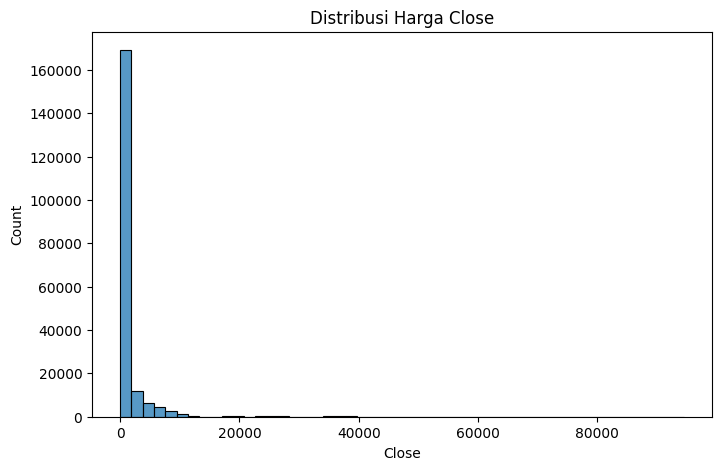

In [22]:
# Visualisasi Distribusi Harga Close
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Close'], bins=50)
plt.title("Distribusi Harga Close")
plt.show()

**Insight:**

Distribusi harga `Close` terlihat sangat tidak merata (*right-skewed*), di mana sebagian besar data berada di harga rendah, sementara hanya sedikit saham yang memiliki harga sangat tinggi (*outlier*). Ini menunjukkan bahwa mayoritas saham diperdagangkan di kisaran harga murah, sedangkan beberapa saham mahal menarik distribusi ke kanan.

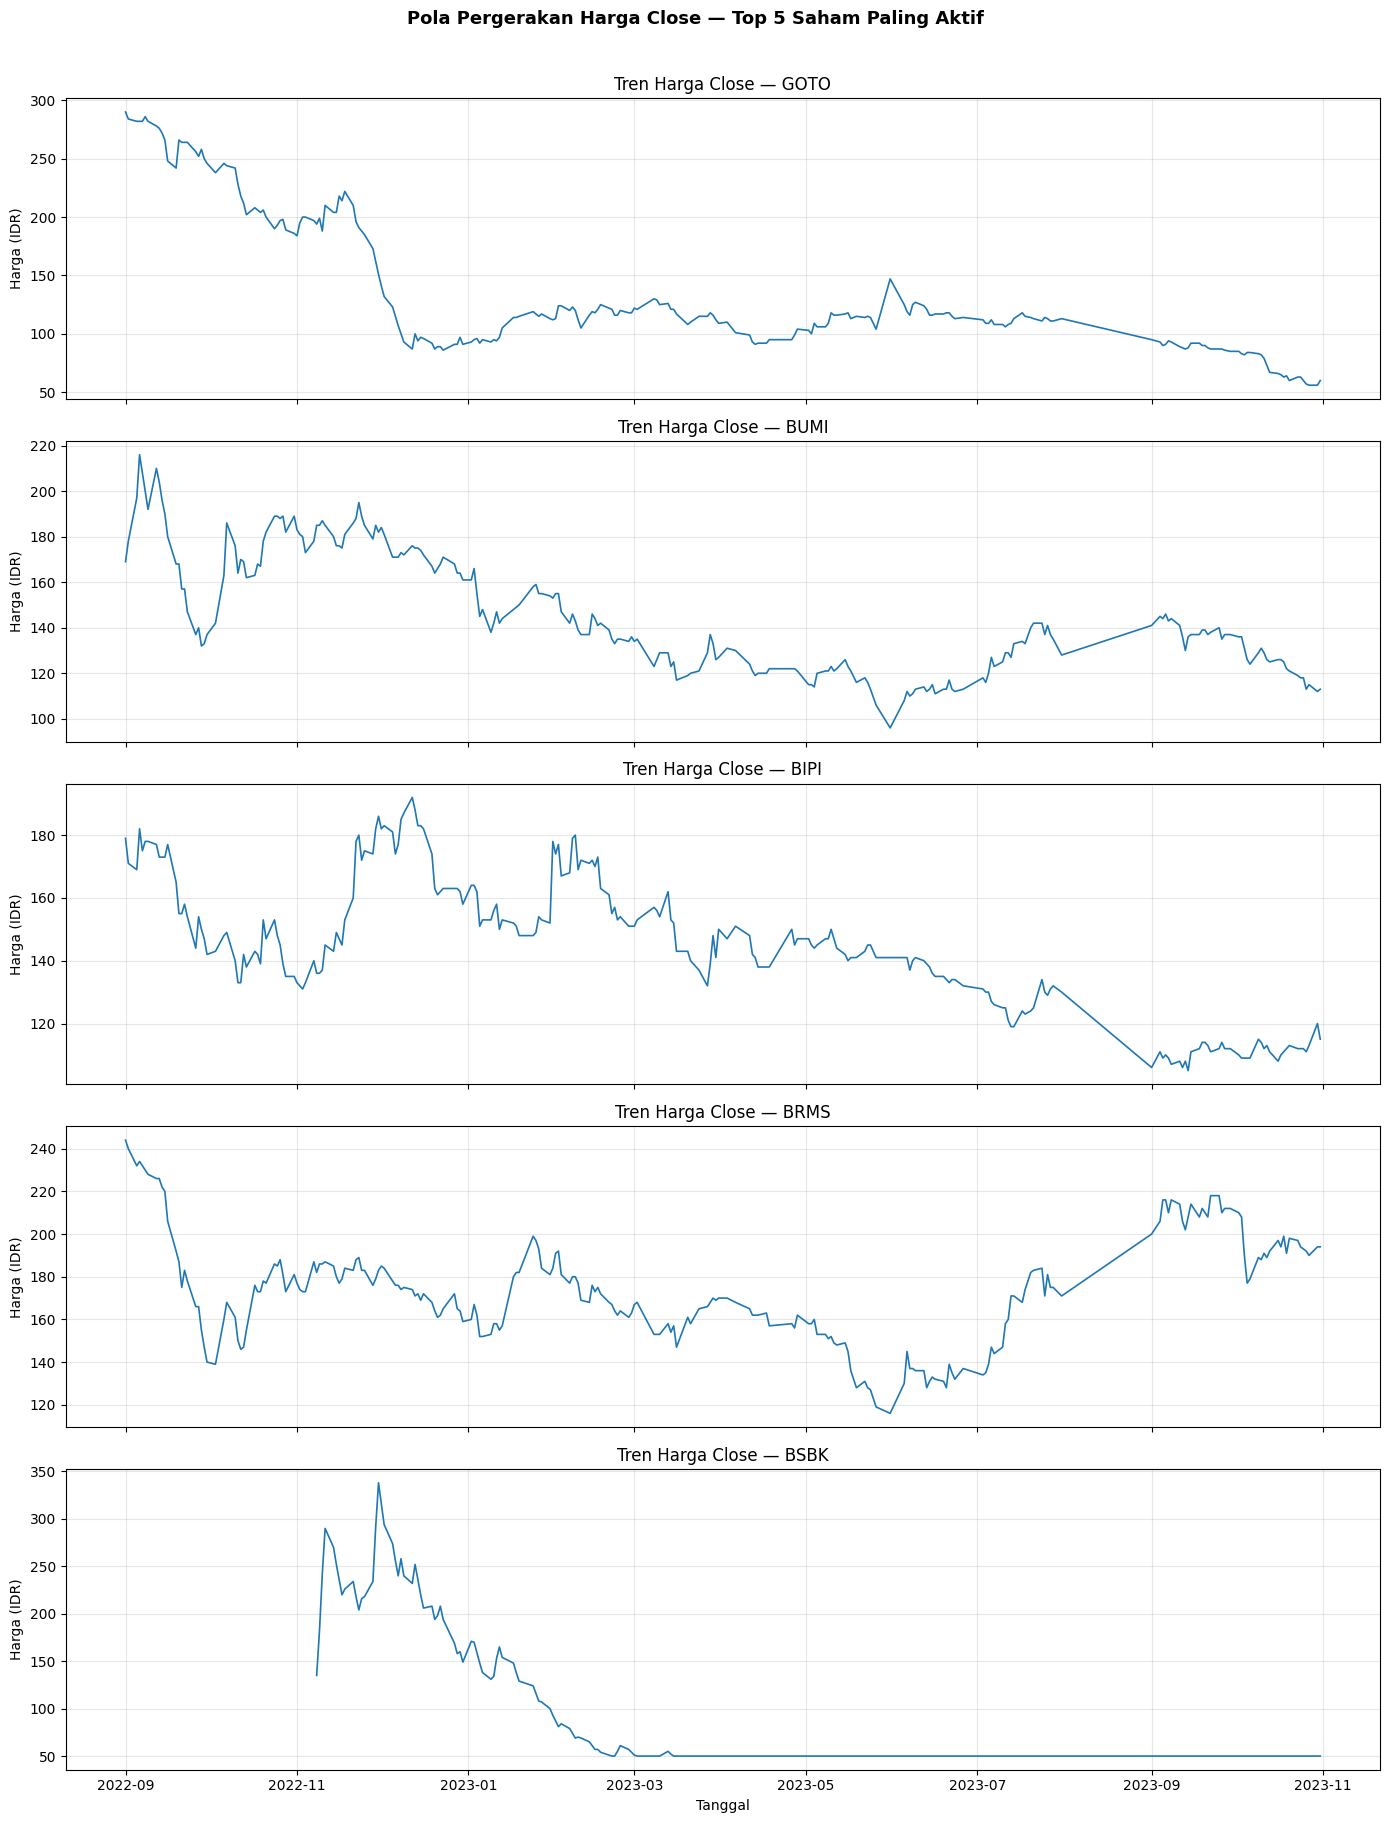

In [23]:
# Top 5 saham paling aktif
top5_stocks = (
    df_clean.groupby('Stock Code')['Volume']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

for i, stock in enumerate(top5_stocks):
    data = df_clean[df_clean['Stock Code'] == stock]

    axes[i].plot(
        data['Last Trading Date'],
        data['Close'],
        linewidth=1.2
    )

    axes[i].set_title(f'Tren Harga Close — {stock}')
    axes[i].set_ylabel('Harga (IDR)')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tanggal')

plt.suptitle(
    'Pola Pergerakan Harga Close — Top 5 Saham Paling Aktif',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.show()

**Insight:**

Dari September 2022 hingga Oktober 2023 kelima saham menunjukkan pola yang berbeda, antara lain:
1. GOTO: menurun terus dari awal hingga akhir
2. BUMI: sempat turun, naik sedikit, lalu turun lagi (cukup fluktuatif)
3. BIPI: turun perlahan dan relatif lebih stabil
4. BRMS: sempat turun lalu naik lagi cukup kuat
5. BSBK: sempat naik, namun akhirnya melonjak turun dan tidak mengalami kenaikan / datar 

Berdasarkan hal tersebut, data ini cocok untuk menguji indikator RSI dan Moving Average pada berbagai kondisi pasar.

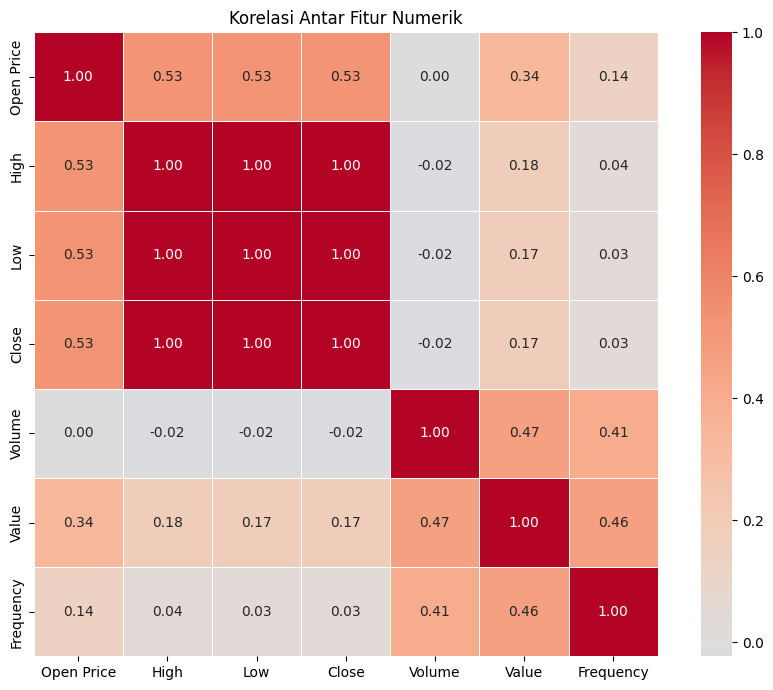

In [24]:
# Korelasi antar fitur numerik
numeric_cols = ['Open Price', 'High', 'Low', 'Close', 'Volume', 'Value', 'Frequency']

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

**Insight:**

- Harga High, Low, dan Close selalu sama (korelasi 1.00), yang artinya
kalau salah satu naik, yang lain juga ikut naik, karena ketiganya sama-sama mencerminkan harga saham di hari yang sama. Tapi, Open Price (0.52) sedikit berbeda karena harga pembukaan kadang bisa langsung naik atau turun jauh dari harga kemarin.
- Volume perdagangan hampir tidak ada hubungannya dengan harga saham (0.00). Artinya saham yang harganya mahal
belum tentu ramai diperdagangkan, dan saham murah pun bisa sangat ramai.
- Value dan Frequency cukup sejalan dengan Volume (sekitar 0.40-0.47), semakin banyak transaksi terjadi, semakin besar nilai dan frekuensi perdagangannya.

Dengan begitu, kolom `Close` akan digunakan untuk analisis lanjutkan, yaitu menghitung RSI dan Moving Average. `Volume` hanya sebagai informasi tambahan likuiditas saham.

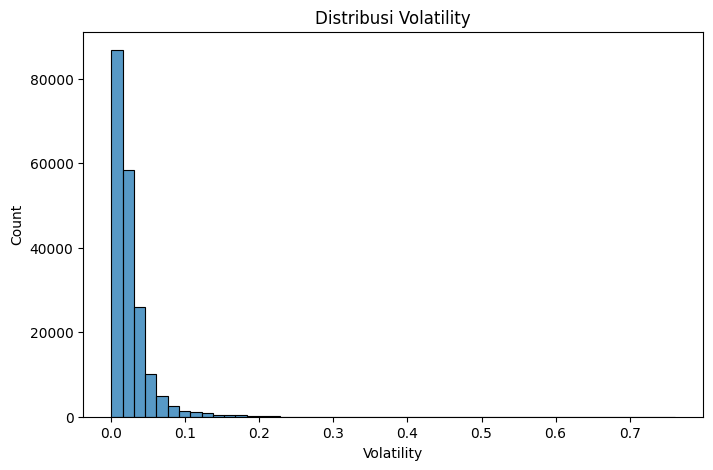

In [26]:
# Menghitung Return Saham
df_clean['Return'] = df_clean.groupby('Stock Code')['Close'].pct_change()

#Analisis Volatility (Risiko)
df_clean['Volatility'] = df_clean.groupby('Stock Code')['Return'].rolling(5).std().reset_index(0,drop=True)

plt.figure(figsize=(8,5))
sns.histplot(df_clean['Volatility'].dropna(), bins=50)
plt.title("Distribusi Volatility")
plt.show()

**Insight:**
- **Mayoritas saham memiliki volatility rendah.** Dari grafik terlihat bahwa sebagian besar nilai volatility terkonsentrasi di kisaran 0 hingga 0.05. Ini menunjukkan bahwa pergerakan harga saham cenderung stabil dan tidak mengalami fluktuasi besar dalam periode pengamatan.
- **Terdapat sebagian kecil saham dengan risiko tinggi.** Meskipun mayoritas stabil, ada beberapa titik data dengan nilai volatility yang cukup tinggi hingga di atas 0.2. Ini menandakan adanya saham dengan pergerakan harga yang sangat fluktuatif.
- **Distribusi data condong ke kanan (*right-skewed*).** Pola distribusi menunjukkan bahwa sebagian besar data berada di nilai rendah, sementara hanya sedikit yang berada di nilai tinggi. Artinya, saham berisiko tinggi jumlahnya lebih sedikit dibandingkan saham stabil.

**Kesimpulan:** Secara keseluruhan, dataset didominasi oleh saham dengan tingkat risiko rendah hingga menengah. Namun, tetap terdapat variasi risiko yang penting, di mana beberapa saham memiliki potensi return tinggi tetapi dengan risiko yang juga besar. Variabel volatility ini menjadi penting dalam modeling karena dapat membantu model memahami tingkat risiko dari setiap saham.

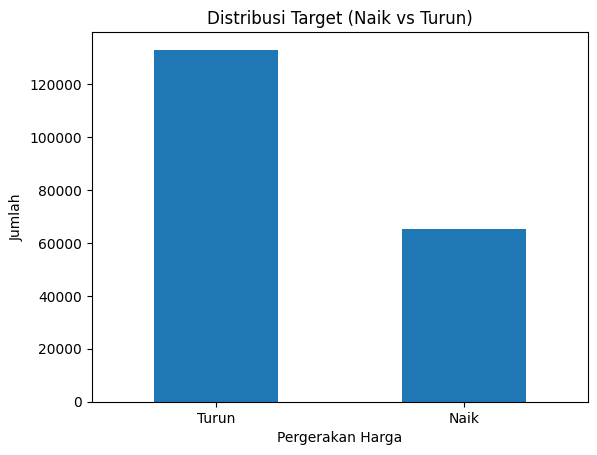

In [27]:

#Analisis Target (Naik vs Turun)
df_clean['Target'] = (df_clean['Change'] > 0).astype(int)
df_clean['Target_Label'] = df_clean['Target'].map({0: 'Turun', 1: 'Naik'})

df_clean['Target_Label'].value_counts().plot(kind='bar')

plt.title("Distribusi Target (Naik vs Turun)")
plt.xlabel("Pergerakan Harga")
plt.ylabel("Jumlah")

plt.xticks(rotation=0)  # biar lurus
plt.show()

**Insight:**
- **Data didominasi oleh kondisi “turun”.** Dari grafik terlihat bahwa jumlah data dengan label `harga turun` jauh lebih banyak dibandingkan label `harga naik`. Artinya, dalam periode data yang digunakan, pergerakan harga saham lebih sering mengalami penurunan dibandingkan kenaikan.
- **Terjadi ketidakseimbangan kelas (*imbalanced data*).** Perbandingan antara kelas `harga turun` dan `harga naik` tidak seimbang (sekitar 2:1). Kondisi ini disebut sebagai class imbalance, di mana salah satu kelas memiliki jumlah data yang jauh lebih banyak dibandingkan kelas lainnya.
- **Potensi bias pada model prediksi.** Jika kondisi ini tidak ditangani, model machine learning cenderung akan lebih sering memprediksi kelas mayoritas (turun). Hal ini bisa membuat model terlihat memiliki akurasi tinggi, tetapi sebenarnya kurang baik dalam mendeteksi kondisi naik (yang justru penting dalam pengambilan keputusan investasi).

**Kesimpulan:** Distribusi target menunjukkan bahwa data tidak seimbang, dengan dominasi pada kondisi harga turun. Hal ini menjadi perhatian penting sebelum masuk ke tahap modeling, karena dapat memengaruhi performa model.

Untuk menghasilkan model yang lebih akurat dan adil, perlu dipertimbangkan teknik penanganan imbalance seperti penggunaan metrik evaluasi yang tepat (*precision, recall, F1-score*) atau metode balancing data seperti oversampling dan undersampling. Selain itu, insight ini juga memberikan gambaran bahwa pasar dalam periode tersebut cenderung bearish (lebih sering turun), sehingga model yang dibangun harus mampu menangkap pola ini tanpa mengabaikan peluang kenaikan harga saham.

# **FEATURE ENGINEERING**

Tahap ini merupakan dasar untuk mengidentifikasi sinyal investasi dan untuk membuat fitur baru yang lebih informatif. Terdapat dua indikator yang akan dihitung, antara lain:
1. ***Moving Average***: untuk rata-rata harga `Close` dalam sejumlah hari tertentu, dan melihat arah tren harga secara lebih halus tanpa terpengaruh oleh naik atau turunnya harga harian yang terlalu ekstrem.
- MA5 (jangka pendek): rata-rata lima hari terakhir
- MA20 (jangka menengah): rata-rata 20 hari terakhir

Cara baca:
- MA5 > MA20, sinyal *Buy*, tren sedang naik
- MA5 < MA20, sinyal *Sell*, tren sedang turun
- MA5 = MA20, sinyal *Hold*, tren sedang *sideways*

2. ***Relative Strength Index*** (RSI): untuk mengukur kekuatan pergerakan harga, nilai selalu berada diantara 0-100 untuk memudahkan dibaca. Akan menggunakan window 14 hari karena sesuai dengan standar analisis.

Cara baca:
- RSI > 70, sinyal *Sell* (harga sudah terlalu tinggi dan kemungkinan turun)
- RSI < 30, sinyal *Buy* (harga sudah terllau rendah dan kemungkinan akan naik)
- RSI 30-70, sinyak *Hold* (harga masih dalam kondisi normal)

Untuk memastikan bahwa perhitungan untuk masing-masing saham tidak tercampur satu sama lain, maka semua indikator akan dihitung berdasarkan kode saham nya.

In [28]:
# Hitung MA5 dan MA20 per saham
df_clean['MA5'] = df_clean.groupby('Stock Code')['Close'].transform(
    lambda x: x.rolling(window=5).mean()
)
df_clean['MA20'] = df_clean.groupby('Stock Code')['Close'].transform(
    lambda x: x.rolling(window=20).mean()
)

# Sinyal tren (1 = Bullish, 0 = Bearish)
df_clean['MA_Signal'] = (df_clean['MA5'] > df_clean['MA20']).astype(int)

# Crossover (1 = Golden Cross/Buy, -1 = Death Cross/Sell)
df_clean['MA_Crossover'] = df_clean.groupby('Stock Code')['MA_Signal'].diff()

# Deviasi harga terhadap MA20 (%)
df_clean['Dist_MA20'] = ((df_clean['Close'] - df_clean['MA20']) / df_clean['MA20']) * 100

# Arah tren MA20
df_clean['MA20_Dir'] = df_clean.groupby('Stock Code')['MA20'].diff()

# Preview hasil
cols = ['Stock Code', 'Last Trading Date', 'Close', 'MA5', 'MA20', 'MA_Crossover', 'Dist_MA20', 'MA20_Dir']
print(df_clean[cols].tail(10))

       Stock Code Last Trading Date  Close    MA5   MA20  MA_Crossover  \
198029       ZYRX        2023-10-18    193 194.40 204.85          0.00   
198030       ZYRX        2023-10-19    194 194.20 203.95          0.00   
198031       ZYRX        2023-10-20    192 194.20 202.45          0.00   
198032       ZYRX        2023-10-23    185 192.20 200.70          0.00   
198033       ZYRX        2023-10-24    190 190.80 199.40          0.00   
198034       ZYRX        2023-10-25    193 190.80 198.65          0.00   
198035       ZYRX        2023-10-26    190 190.00 197.95          0.00   
198036       ZYRX        2023-10-27    187 189.00 197.20          0.00   
198037       ZYRX        2023-10-30    187 189.40 196.45          0.00   
198038       ZYRX        2023-10-31    179 187.20 195.40          0.00   

        Dist_MA20  MA20_Dir  
198029      -5.78     -1.45  
198030      -4.88     -0.90  
198031      -5.16     -1.50  
198032      -7.82     -1.75  
198033      -4.71     -1.30  
19803

**Cara baca indikator MA:**
- **MA_Crossover (Sinyal):** Penentu waktu transaksi. Nilai 1 menunjukkan ***Golden Cross*** (MA5 memotong MA20 dari bawah ke atas) yang merupakan sinyal beli. Nilai -1 menunjukkan ***Death Cross*** yang merupakan sinyal jual. Nilai 0 berarti belum ada sinyal baru.
- **Dist_MA20 (Jarak):** Penentu posisi harga terhadap tren. Mengukur seberapa jauh harga penutupan dari MA20 dalam persentase. Nilai positif berarti harga berada di atas MA20 (relatif kuat), sedangkan nilai negatif berarti harga berada di bawah MA20 (relatif lemah).
- **MA20_Dir (Arah):** Penentu arah tren menengah. Nilai positif menunjukkan MA20 sedang naik (***uptrend***), sedangkan nilai negatif menunjukkan MA20 sedang turun (***downtrend***).

**Insight:**

Berdasarkan 10 data terakhir saham ZYRX, harga penutupan cenderung menurun dari 193 menjadi 179. Nilai MA_Crossover yang selalu 0 menunjukkan belum ada sinyal beli maupun jual. Nilai Dist_MA20 yang negatif menandakan harga berada di bawah MA20, sedangkan MA20_Dir yang juga negatif menunjukkan tren masih menurun. Secara sederhana, saham ZYRX masih berada dalam kondisi bearish dan belum menunjukkan tanda kenaikan.

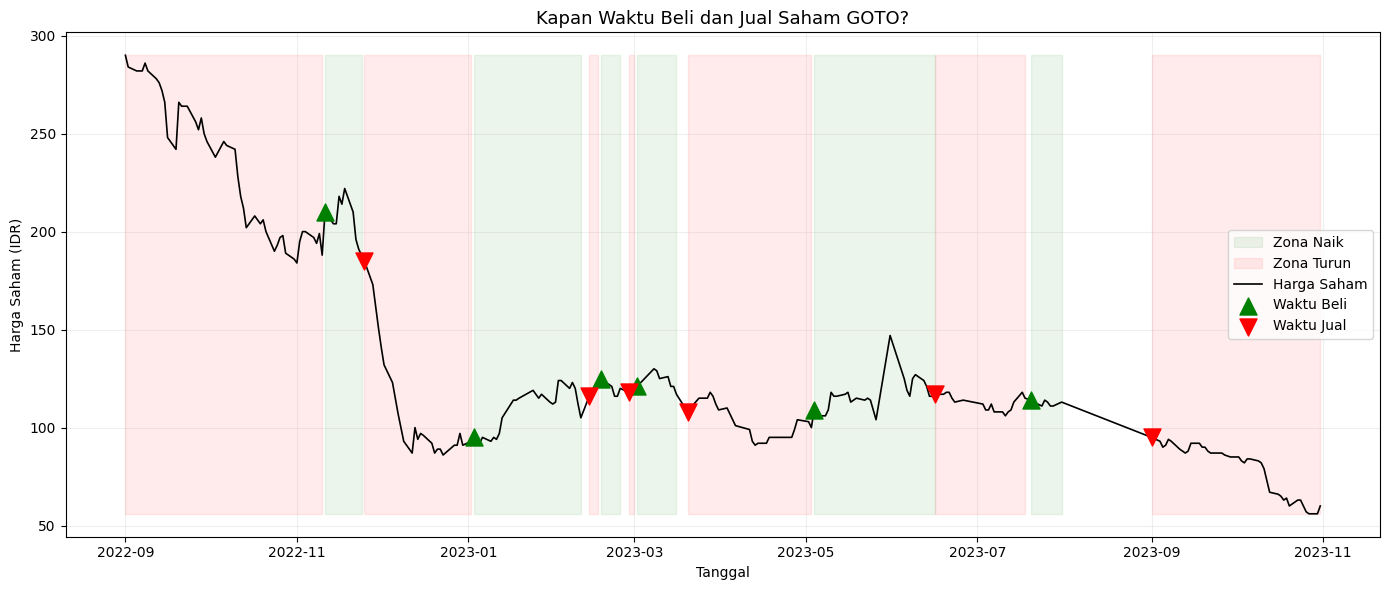

In [29]:
# Visualisasi sinyal beli dan jual saham
target = 'GOTO'
df_plot = df_clean[df_clean['Stock Code'] == target].copy()

plt.figure(figsize=(14, 6))

# Zona naik dan turun
plt.fill_between(df_plot['Last Trading Date'],
                 df_plot['Close'].min(), df_plot['Close'].max(),
                 where=(df_plot['MA_Signal'] == 1),
                 color='green', alpha=0.08, label='Zona Naik')

plt.fill_between(df_plot['Last Trading Date'],
                 df_plot['Close'].min(), df_plot['Close'].max(),
                 where=(df_plot['MA_Signal'] == 0),
                 color='red', alpha=0.08, label='Zona Turun')

# Harga saham
plt.plot(df_plot['Last Trading Date'], df_plot['Close'],
         color='black', linewidth=1.2, label='Harga Saham')

# Sinyal beli dan jual
buy = df_plot[df_plot['MA_Crossover'] == 1]
sell = df_plot[df_plot['MA_Crossover'] == -1]

plt.scatter(buy['Last Trading Date'], buy['Close'],
            marker='^', color='green', s=150, zorder=5, label='Waktu Beli')
plt.scatter(sell['Last Trading Date'], sell['Close'],
            marker='v', color='red', s=150, zorder=5, label='Waktu Jual')

plt.title(f'Kapan Waktu Beli dan Jual Saham {target}?', fontsize=13)
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham (IDR)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan grafik saham GOTO, harga saham menunjukkan tren menurun dari sekitar 290 pada September 2022 hingga mendekati 60 pada akhir Oktober 2023. Sinyal beli (segitiga hijau) muncul ketika harga mulai menguat di area tren naik, sedangkan sinyal jual (segitiga merah) muncul saat harga mulai melemah atau memasuki tren turun. Beberapa sinyal beli pada awal 2023 sempat diikuti kenaikan harga ke kisaran 120-130, namun tren penurunan jangka panjang masih mendominasi. Pada paruh kedua 2023, harga kembali bergerak turun meskipun sempat muncul sinyal beli. Secara keseluruhan, strategi Moving Average mampu memberikan titik masuk dan keluar yang cukup jelas, tetapi saham GOTO masih berada dalam tren bearish sehingga investor perlu lebih berhati-hati dalam mengambil keputusan.

In [30]:
# Backtesting sinyal MA Crossover
trades = df_plot[df_plot['MA_Crossover'].isin([1, -1])].copy()
trades['Return_Pct'] = trades['Close'].pct_change() * 100

hasil = trades[trades['MA_Crossover'] == -1][['Last Trading Date', 'Close', 'Return_Pct']]
total = hasil['Return_Pct'].sum()

print(f"Hasil Transaksi: {target}")
print(hasil.to_string(index=False))
print(f"\nTotal Profit/Loss: {total:.2f}%")

Hasil Transaksi: GOTO
Last Trading Date  Close  Return_Pct
       2022-11-25    185      -11.90
       2023-02-13    116       22.11
       2023-02-27    118       -5.60
       2023-03-20    108      -10.74
       2023-06-16    117        7.34
       2023-09-01     95      -16.67

Total Profit/Loss: -15.47%


**Insight:**

Kolom Return_Pct: keuntungan atau kerugian dalam persen dibanding harga beli sebelumnya
  - Nilai positif (+) = untung
  - Nilai negatif (-) = rugi

Berdasarkan hasil backtesting pada saham GOTO menghasilkan kerugian total sebesar -15.47% selama periode September 2022 hingga Oktober 2023. Dari enam transaksi jual, hanya dua yang memberikan keuntungan, empat lainnya mengalami kerugian.

In [31]:
# Hitung RSI per saham (window 14 hari)
df_clean['RSI'] = df_clean.groupby('Stock Code')['Close'].transform(
    lambda x: ta.momentum.RSIIndicator(x, window=14).rsi()
)

# Sinyal RSI
df_clean['RSI_Signal'] = df_clean['RSI'].apply(
    lambda x: 'Buy' if x < 30 else ('Sell' if x > 70 else 'Hold')
)

# Preview hasil
print(df_clean[['Stock Code', 'Last Trading Date', 'Close', 'RSI', 'RSI_Signal']].tail(10))

       Stock Code Last Trading Date  Close   RSI RSI_Signal
198029       ZYRX        2023-10-18    193 35.18       Hold
198030       ZYRX        2023-10-19    194 36.30       Hold
198031       ZYRX        2023-10-20    192 34.99       Hold
198032       ZYRX        2023-10-23    185 30.81       Hold
198033       ZYRX        2023-10-24    190 36.64       Hold
198034       ZYRX        2023-10-25    193 39.90       Hold
198035       ZYRX        2023-10-26    190 37.80       Hold
198036       ZYRX        2023-10-27    187 35.78       Hold
198037       ZYRX        2023-10-30    187 35.78       Hold
198038       ZYRX        2023-10-31    179 30.69       Hold


**Insight:**

Berdasarkan 10 data terakhir saham ZYRX, nilai RSI bergerak di kisaran 30.70 hingga 39.90. Seluruh nilai RSI masih berada pada status `Hold`, yang berarti belum muncul sinyal beli (RSI < 30) maupun sinyal jual (RSI > 70). Meskipun pada 31 Oktober 2023 RSI turun ke 30,69 dan mendekati area oversold, nilainya masih belum cukup rendah untuk memicu sinyal beli. Secara keseluruhan, momentum saham ZYRX masih lemah dan investor disarankan menunggu konfirmasi sinyal yang lebih jelas sebelum mengambil keputusan transaksi.

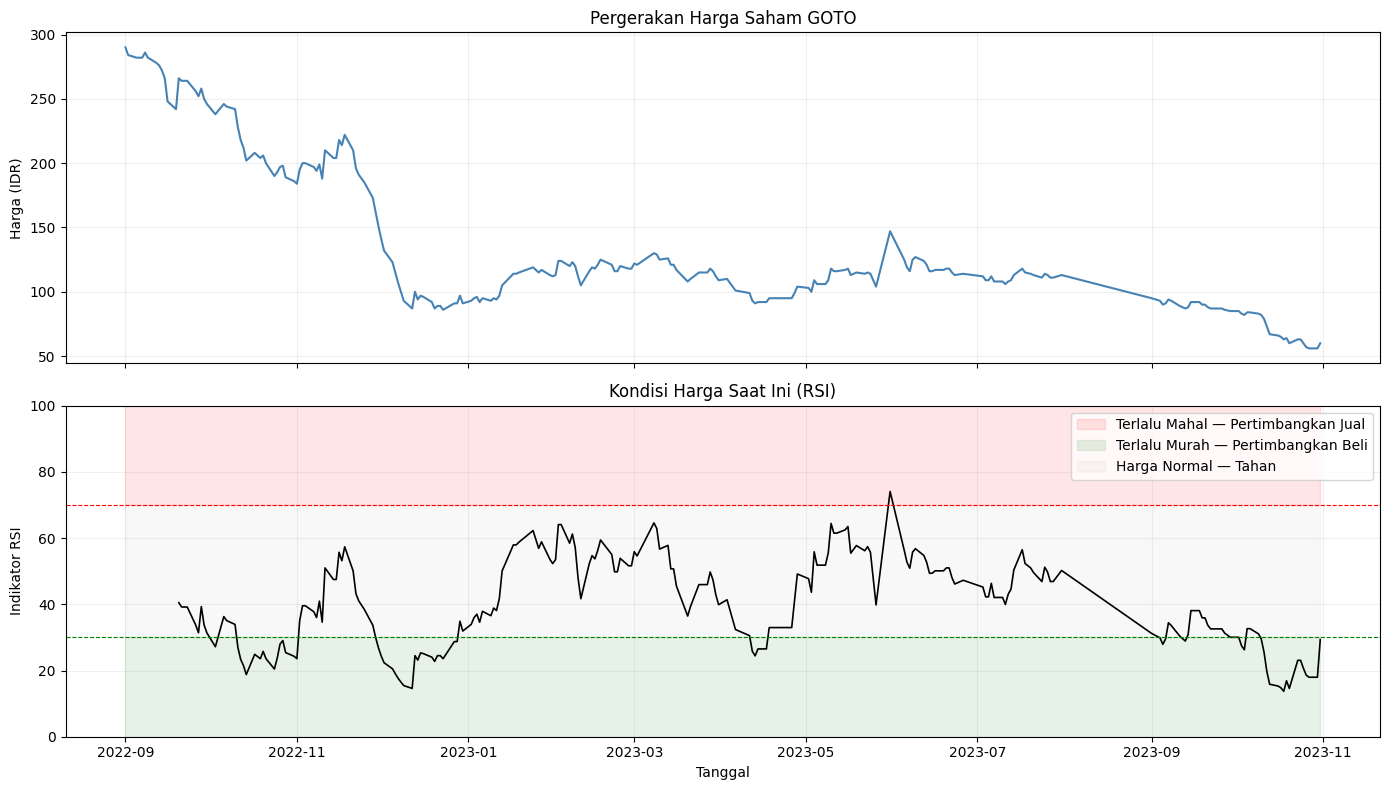

In [32]:
# Visualisasi RSI
target = 'GOTO'
df_plot = df_clean[df_clean['Stock Code'] == target].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot harga
axes[0].plot(df_plot['Last Trading Date'], df_plot['Close'],
             color='steelblue', linewidth=1.5)
axes[0].set_title(f'Pergerakan Harga Saham {target}', fontsize=12)
axes[0].set_ylabel('Harga (IDR)')
axes[0].grid(True, alpha=0.2)

# Plot RSI dengan zona berwarna
axes[1].plot(df_plot['Last Trading Date'], df_plot['RSI'],
             color='black', linewidth=1.2)

# Zona merah = terlalu mahal
axes[1].fill_between(df_plot['Last Trading Date'], 70, 100,
                     color='red', alpha=0.1, label='Terlalu Mahal — Pertimbangkan Jual')

# Zona hijau = terlalu murah
axes[1].fill_between(df_plot['Last Trading Date'], 0, 30,
                     color='green', alpha=0.1, label='Terlalu Murah — Pertimbangkan Beli')

# Zona abu = normal
axes[1].fill_between(df_plot['Last Trading Date'], 30, 70,
                     color='gray', alpha=0.05, label='Harga Normal — Tahan')

axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8)
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8)

axes[1].set_title('Kondisi Harga Saat Ini (RSI)', fontsize=12)
axes[1].set_ylabel('Indikator RSI')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan visualisasi, harga saham GOTO terus mengalami penurunan dari sekitar 290 pada September 2022 menjadi sekitar 60 pada akhir Oktober 2023. Nilai RSI sebagian besar berada pada kisaran normal (30-70), namun pada beberapa periode, termasuk di akhir Oktober 2023, RSI turun di bawah 30. Kondisi ini menunjukkan bahwa harga saham telah turun terlalu dalam (oversold), sehingga saham terlihat relatif murah dibanding pergerakan sebelumnya. Dalam kondisi seperti ini, terdapat peluang harga untuk naik kembali dalam jangka pendek (rebound), meskipun tren utamanya masih cenderung menurun.

In [33]:
# Gabungkan RSI dan MA menjadi rekomendasi akhir
def combined_signal(row):
    if row['RSI_Signal'] == 'Buy' and row['MA_Crossover'] == 1:
        return 'Strong Buy'
    elif row['RSI_Signal'] == 'Sell' and row['MA_Crossover'] == -1:
        return 'Strong Sell'
    elif row['RSI_Signal'] == 'Buy' or row['MA_Crossover'] == 1:
        return 'Buy'
    elif row['RSI_Signal'] == 'Sell' or row['MA_Crossover'] == -1:
        return 'Sell'
    else:
        return 'Hold'

df_clean['Final_Signal'] = df_clean.apply(combined_signal, axis=1)

# Preview hasil
print(df_clean[['Stock Code', 'Last Trading Date', 'Close', 'RSI', 'RSI_Signal', 'MA_Crossover', 'Final_Signal']].tail(10))

       Stock Code Last Trading Date  Close   RSI RSI_Signal  MA_Crossover  \
198029       ZYRX        2023-10-18    193 35.18       Hold          0.00   
198030       ZYRX        2023-10-19    194 36.30       Hold          0.00   
198031       ZYRX        2023-10-20    192 34.99       Hold          0.00   
198032       ZYRX        2023-10-23    185 30.81       Hold          0.00   
198033       ZYRX        2023-10-24    190 36.64       Hold          0.00   
198034       ZYRX        2023-10-25    193 39.90       Hold          0.00   
198035       ZYRX        2023-10-26    190 37.80       Hold          0.00   
198036       ZYRX        2023-10-27    187 35.78       Hold          0.00   
198037       ZYRX        2023-10-30    187 35.78       Hold          0.00   
198038       ZYRX        2023-10-31    179 30.69       Hold          0.00   

       Final_Signal  
198029         Hold  
198030         Hold  
198031         Hold  
198032         Hold  
198033         Hold  
198034         Hold 

**Insight:**

Berdasarkan 10 data terakhir saham ZYRX, seluruh indikator masih memberikan sinyal Hold. Nilai RSI berada di kisaran 30-40, yang menunjukkan momentum saham masih lemah tetapi belum cukup rendah untuk menghasilkan sinyal beli. Selain itu, MA_Crossover bernilai 0 pada seluruh periode, menandakan belum ada sinyal beli maupun jual dari perpotongan moving average. Dengan demikian, belum terdapat indikasi kuat untuk membeli atau menjual saham ZYRX, sehingga posisi terbaik saat ini adalah menunggu sampai muncul sinyal yang lebih jelas.

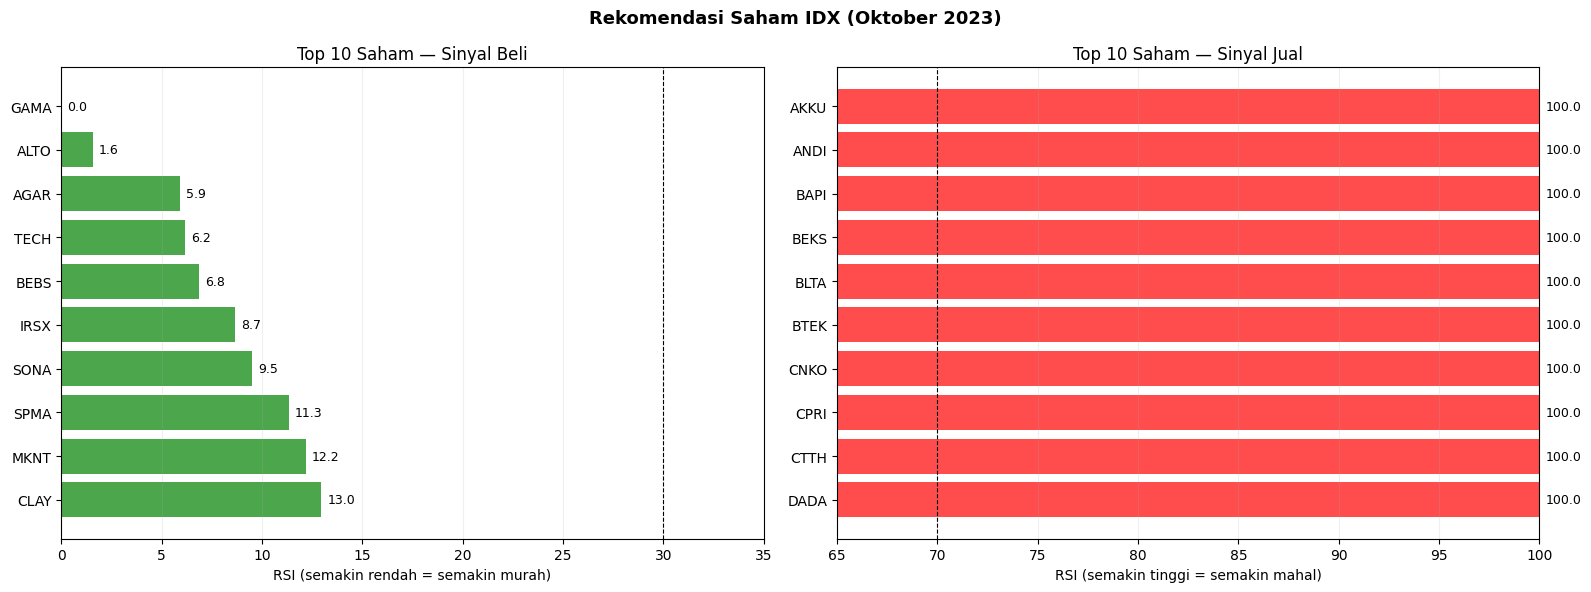

In [34]:
# Top saham Buy (RSI terendah) dan Sell (RSI tertinggi)
latest = df_clean.groupby('Stock Code').last().reset_index()
latest = latest[latest['Final_Signal'].isin(['Buy', 'Sell'])]

top_buy = latest[latest['Final_Signal'] == 'Buy'].nsmallest(10, 'RSI')
top_sell = latest[latest['Final_Signal'] == 'Sell'].nlargest(10, 'RSI')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Buy
axes[0].barh(top_buy['Stock Code'], top_buy['RSI'], color='green', alpha=0.7)
axes[0].axvline(30, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Top 10 Saham — Sinyal Beli', fontsize=12)
axes[0].set_xlabel('RSI (semakin rendah = semakin murah)')
axes[0].set_xlim(0, 35)                     # Tambahkan skala sumbu X
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.2, axis='x')

# Label nilai RSI
for i, v in enumerate(top_buy['RSI']):
    axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

# Top Sell
axes[1].barh(top_sell['Stock Code'], top_sell['RSI'], color='red', alpha=0.7)
axes[1].axvline(70, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Top 10 Saham — Sinyal Jual', fontsize=12)
axes[1].set_xlabel('RSI (semakin tinggi = semakin mahal)')
axes[1].set_xlim(65, 100)                   # Tambahkan skala sumbu X
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.2, axis='x')

# Label nilai RSI
for i, v in enumerate(top_sell['RSI']):
    axes[1].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

plt.suptitle('Rekomendasi Saham IDX (Oktober 2023)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**

Berdasarkan rekomendasi saham IDX per Oktober 2023, terdapat 10 saham dengan sinyal beli dan 10 saham dengan sinyal jual berdasarkan indikator RSI. Pada kelompok sinyal beli, saham seperti GAMA, ALTO, dan AGAR memiliki nilai RSI yang sangat rendah, bahkan mendekati 0, yang menunjukkan bahwa harga saham telah turun cukup dalam dan berada pada kondisi relatif murah. Kondisi ini dapat menjadi peluang bagi investor untuk mempertimbangkan pembelian apabila terdapat konfirmasi tambahan.

Di sisi lain, seluruh saham pada kelompok sinyal jual, seperti AKKU, ANDI, dan BAPI, memiliki nilai RSI sebesar 100. Hal ini menunjukkan bahwa harga saham tersebut mengalami kenaikan yang sangat kuat dalam periode perhitungan RSI dan berada pada kondisi relatif mahal. Saham-saham ini berpotensi mengalami koreksi harga, sehingga investor dapat mempertimbangkan untuk melakukan profit taking atau menunda pembelian.

# **ANALISIS LANJUTAN**

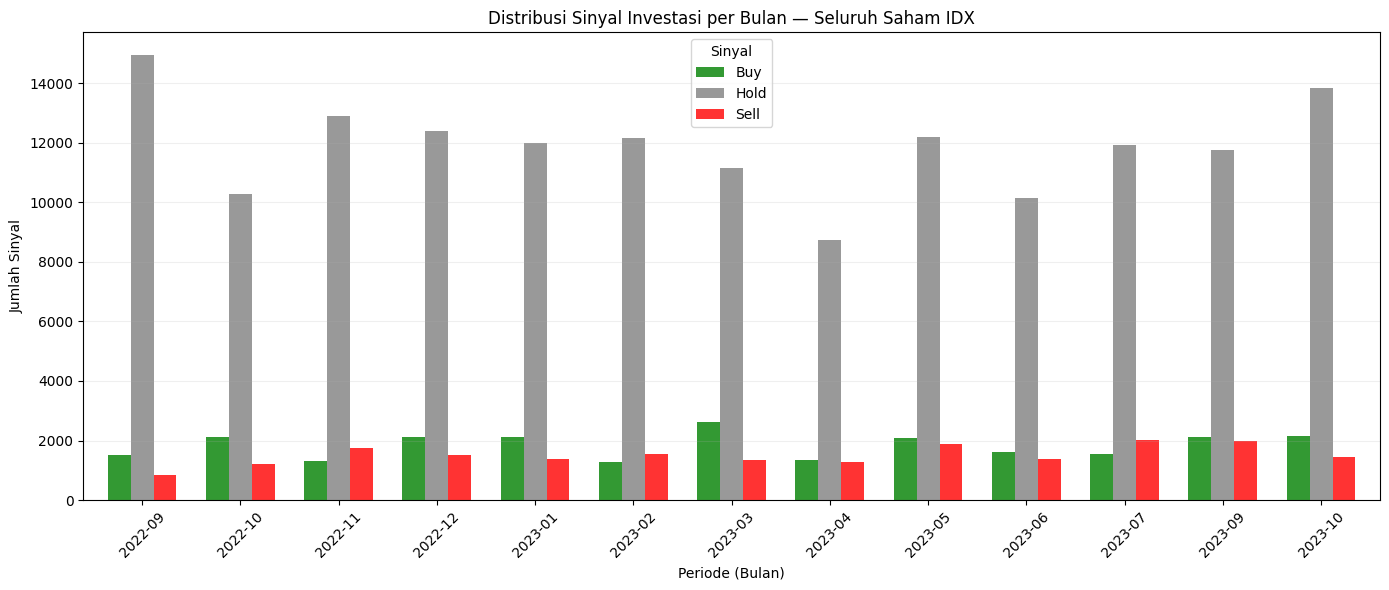

In [36]:
# Distribusi Final Signal per bulan
df_clean['Month'] = df_clean['Last Trading Date'].dt.to_period('M')

signal_monthly = (df_clean.groupby(['Month', 'Final_Signal'])
                  .size()
                  .unstack(fill_value=0))

signal_monthly.index = signal_monthly.index.astype(str)

signal_monthly[['Buy', 'Hold', 'Sell']].plot(
    kind='bar', figsize=(14, 6),
    color=['green', 'gray', 'red'],
    alpha=0.8, width=0.7
)

plt.title('Distribusi Sinyal Investasi per Bulan — Seluruh Saham IDX')
plt.xlabel('Periode (Bulan)')
plt.ylabel('Jumlah Sinyal')
plt.xticks(rotation=45)
plt.legend(title='Sinyal')
plt.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

**Insight:**

Sebagian besar saham di IDX saat ini berada dalam posisi Hold, artinya pasar cenderung stabil atau bergerak menyamping, tidak sedang naik atau turun secara ekstrem. Meskipun pasar terlihat tenang, peluang untuk jual atau beli tetap ada setiap bulannya pada saham-saham tertentu secara spesifik.

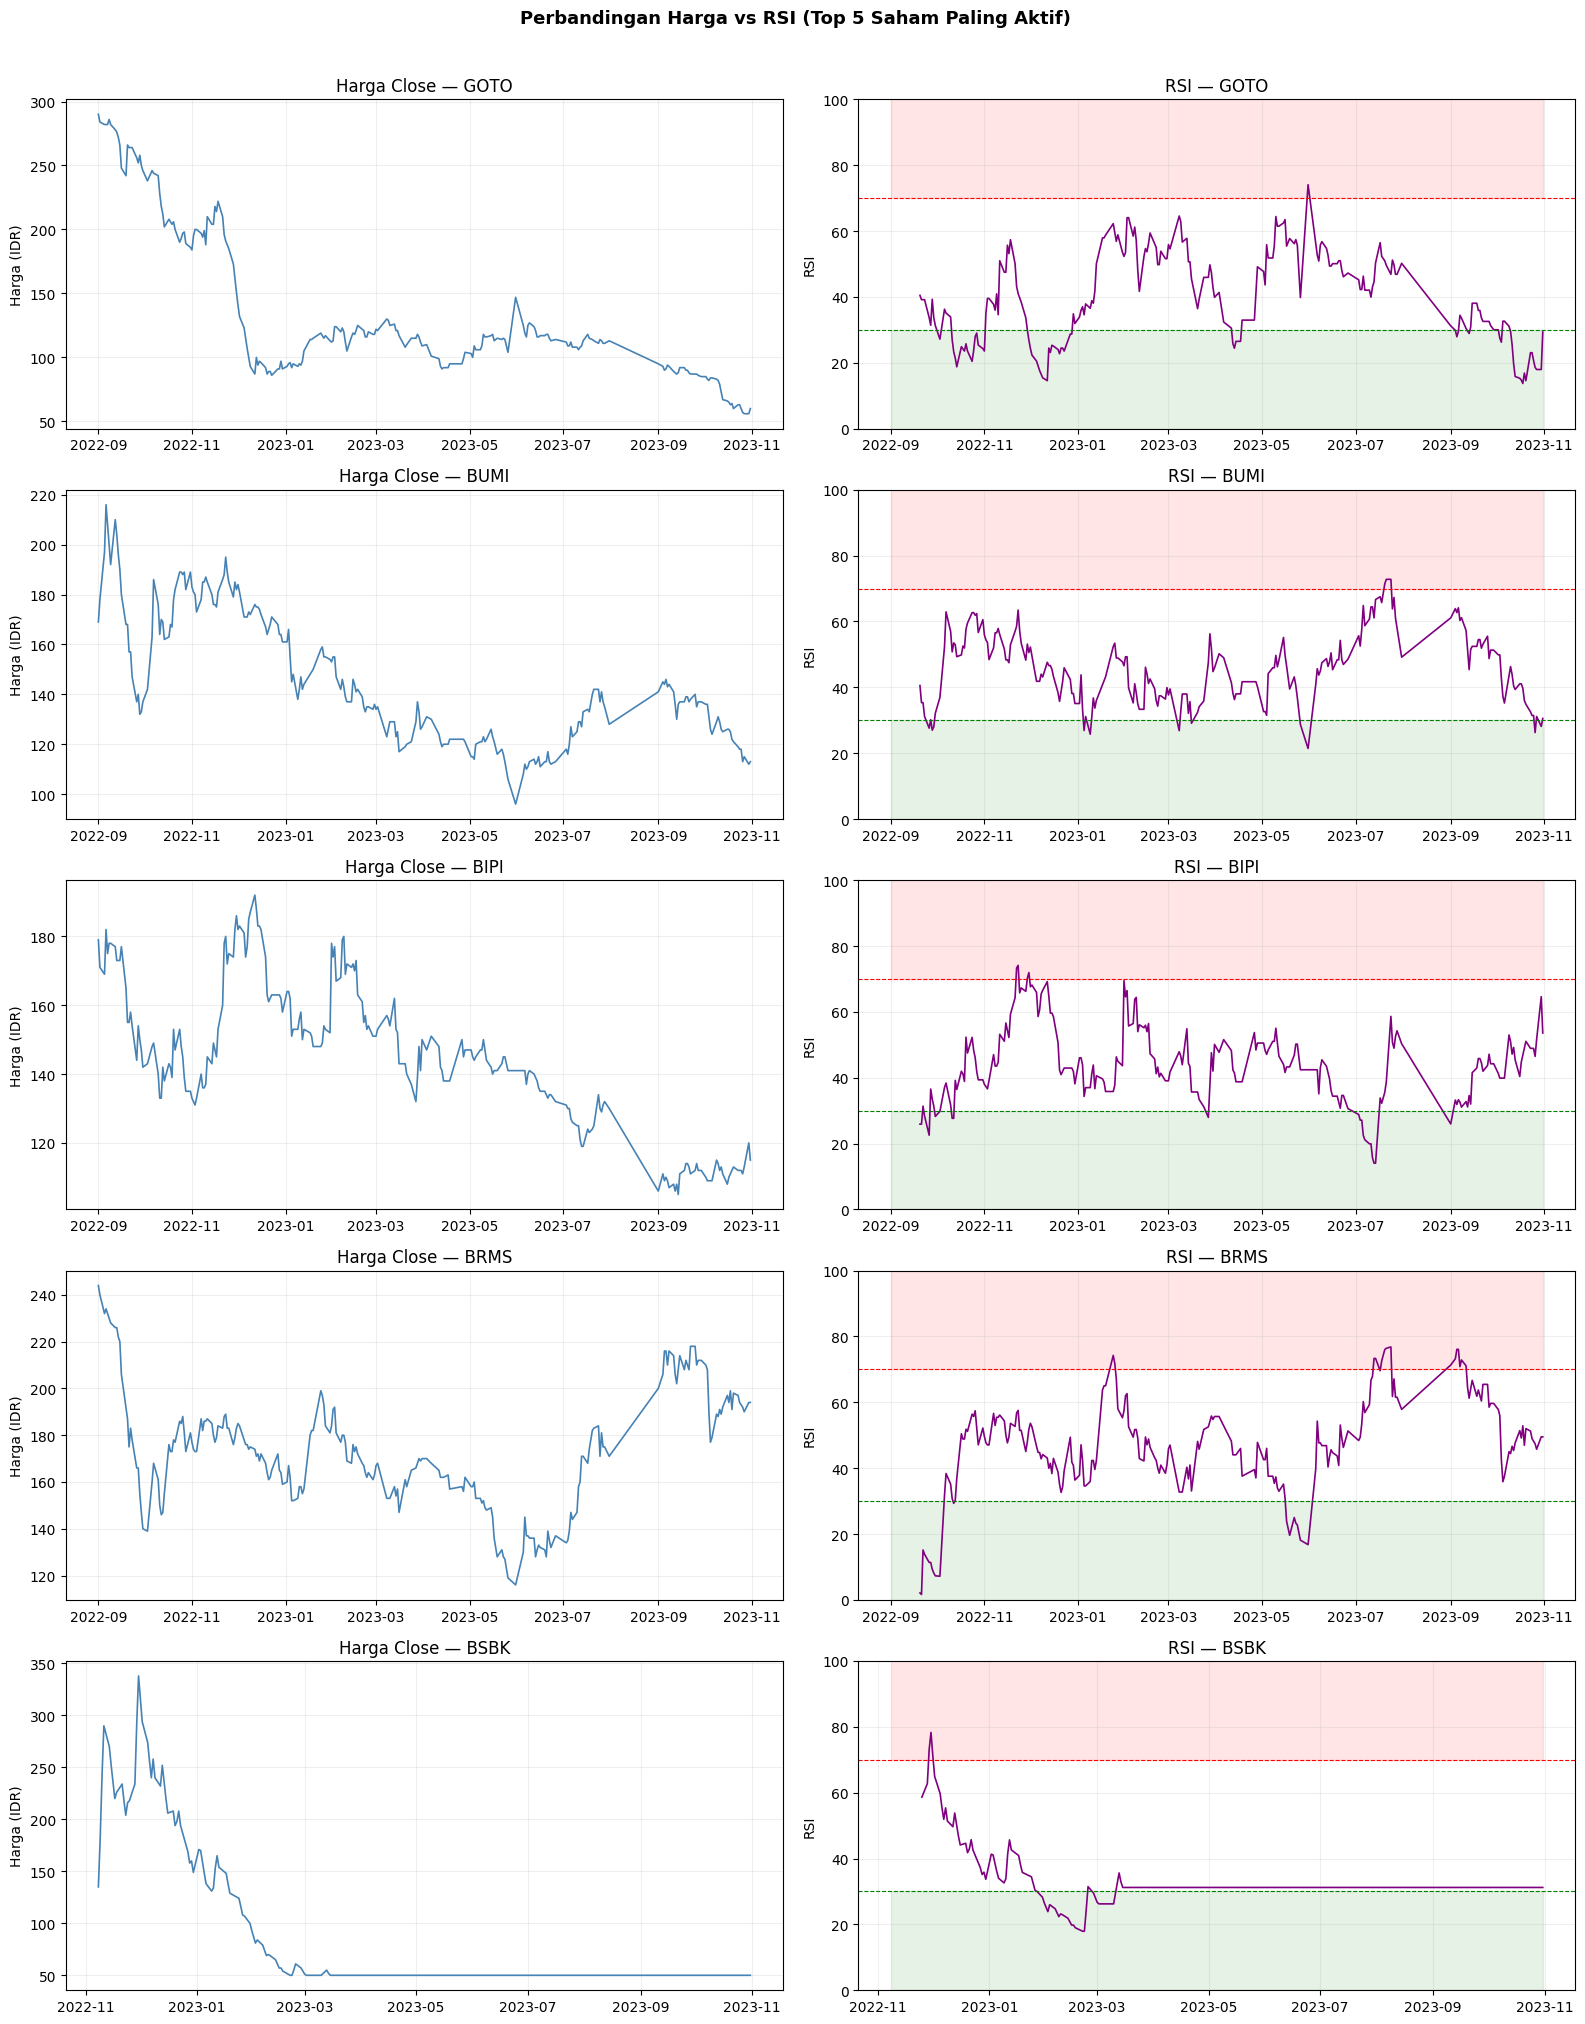

In [37]:
# Perbandingan RSI vs Harga Close (Top 5 saham)
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=False)

for i, stock in enumerate(top5_stocks):
    data = df_clean[df_clean['Stock Code'] == stock].copy()

    # Harga Close
    axes[i][0].plot(data['Last Trading Date'], data['Close'],
                    color='steelblue', linewidth=1.2)
    axes[i][0].set_title(f'Harga Close — {stock}')
    axes[i][0].set_ylabel('Harga (IDR)')
    axes[i][0].grid(True, alpha=0.2)

    # RSI
    axes[i][1].plot(data['Last Trading Date'], data['RSI'],
                    color='purple', linewidth=1.2)
    axes[i][1].axhline(70, color='red', linestyle='--', linewidth=0.8)
    axes[i][1].axhline(30, color='green', linestyle='--', linewidth=0.8)
    axes[i][1].fill_between(data['Last Trading Date'], 0, 30,
                             color='green', alpha=0.1)
    axes[i][1].fill_between(data['Last Trading Date'], 70, 100,
                             color='red', alpha=0.1)
    axes[i][1].set_title(f'RSI — {stock}')
    axes[i][1].set_ylabel('RSI')
    axes[i][1].set_ylim(0, 100)
    axes[i][1].grid(True, alpha=0.2)

plt.suptitle('Perbandingan Harga vs RSI (Top 5 Saham Paling Aktif)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Insight:**

Jika melihat pergerakan harga dan indikator RSI (pengukur jenuh jual/beli), ada beberapa poin penting:

1. **GOTO & BUMI:** Harga saham ini cenderung turun hingga akhir Oktober 2023. Karena nilai RSI-nya masuk ke zona hijau (di bawah 30), ini menandakan harga sudah cukup murah atau "diskon". Investor bisa mulai memantau saham ini untuk peluang beli.

2. **BRMS & BIPI:** Saham ini sempat naik tinggi hingga nilai RSI-nya menyentuh zona merah (di atas 70). Ini menunjukkan harga sudah relatif mahal dan ada risiko harganya akan turun kembali (koreksi), sehingga investor perlu waspada.

3. **INET:** Kekuatan kenaikan harganya mulai melemah seiring dengan nilai RSI yang turun dari zona mahal menuju zona normal. Sebaiknya investor menunggu dulu sampai ada tanda-tanda harga stabil kembali.

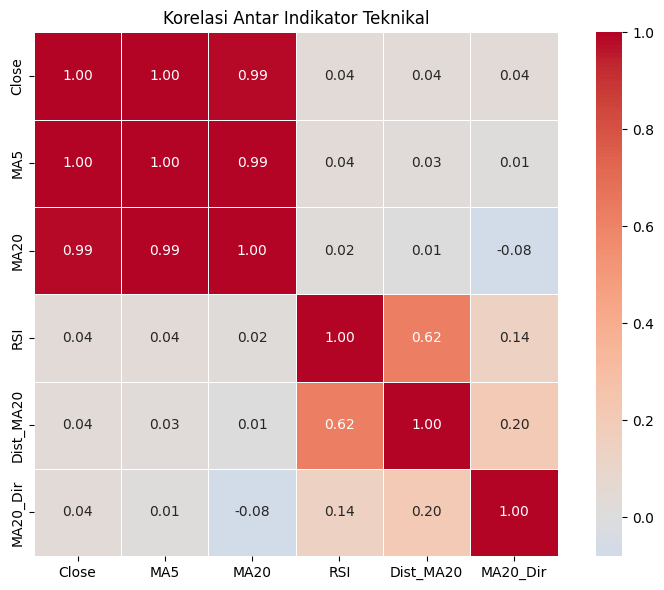

In [38]:
# Korelasi antar indikator teknikal
corr_cols = ['Close', 'MA5', 'MA20', 'RSI', 'Dist_MA20', 'MA20_Dir']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Antar Indikator Teknikal')
plt.tight_layout()
plt.show()

**Insight:**

`Close`, `MA5`, dan `MA20` menunjukkan pola yang hampir sama karena semuanya mencerminkan pergerakan harga, sehingga tidak perlu digunakan bersamaan. `RSI` memberikan informasi yang berbeda karena tidak bergantung langsung pada harga, sementara jarak harga ke `MA20` masih cukup terkait dengan pergerakan `RSI`. Oleh karena itu, menggunakan kombinasi indikator fungsi yang berbeda, seperti MA untuk tren dan RSI untuk momentum, akan membuat analisis lebih jelas dan tidak tumpang tindih.

# **CONCLUSION & RECOMMENDATION**

**Conclusion:**

Berdasarkan analisis yang telah dilakukan pada data saham IDX periode September 2022 hingga Oktober 2023, berikut hal-hal yang dapat disimpulkan:

1. Pasar cenderung diam, karena sebagian besar saham tidak memberikan sinyal beli maupun jual yang kuar sepanjang periode. Kondisi ini mencerminkan pasar yang sedang menunggu dan belum menunjukkan arah yang jelas.
2. Banyak saham turun di akhir periode, saham yang ramai diperdagangkan seperti GOTO dan BUMI terus mengalami penurunan harga, pada akhir Oktober 2023 banyak saham sudah masuk zona murah namun belum ada tanda-tanda akan naik kembali.
3. RSI dan MA saling melengkapi, karena RSI untuk mengukur seberapa mahal atau murah harga saham, sedangkan MA untuk melihat arah trennya.
4. Strategi jual beli tidak selalu menguntungkan, kalau dilihat dari pengujian di saham GOTO, mengikuti semua sinyal beli dan jual menghasilkan kerugian sekitar -10.58%, hal ini menunjukkan bahwa indikator teknikal saja tidak cukup terutama pada saham yang sedang turun terus.

**Recommendation:**

1. Gunakan RSI dan MA secara bersamaan, karena sinyal muncul dari keduanya sekaligus jauh lebih dapat dipercaya dibanding hanya dari satu indikator.
2. Sinyal beli dari RSI tidak selalu harga akan naik, terutama jika pasar sedang dalam tren turun, dan pastikan tren besar sudah berbalik sebelum memutuskan untuk membeli.
3. Saham dengan bolume tinggi menghasilkan sinyal yang lebih stabil dan dapat diandalkan dibanding saham yang jarang diperdagangkan.
4. Indikator teknikal perlu dikombinasikan dengan sentimen berita agar rekomendasi lebih akurat dan tidak terjebak FOMO.

# **Data Dictionary**

Dataset ini merupakan hasil pengolahan data saham IDX periode September 2022 hingga Oktober 2023 yang digunakan untuk analisis teknikal saham pada proyek Anti FOMO Stock Mentor. Dataset telah melalui proses data cleaning, filtering, dan feature engineering untuk menghasilkan indikator teknikal yang siap digunakan pada analisis dan machine learning.

In [40]:
data_dict = pd.DataFrame({
    'Nama Kolom': [
        'No', 'Stock Code', 'Company Name', 'Remarks',
        'Previous', 'Open Price', 'Last Trading Date',
        'First Trade', 'High', 'Low', 'Close', 'Change',
        'Volume', 'Value', 'Frequency', 'Index Individual',
        'Offer', 'Offer Volume', 'Bid', 'Bid Volume',
        'Listed Shares', 'Tradeble Shares', 'Weight For Index',
        'Foreign Sell', 'Foreign Buy',
        'Non Regular Volume', 'Non Regular Value',
        'Non Regular Frequency',
        'Return', 'Return_Pct', 'Volatility',
        'MA5', 'MA20', 'MA_Signal',
        'MA20_Dir', 'MA_Crossover',
        'Dist_MA20', 'RSI', 'RSI_Signal'
    ],

    'Tipe Data': [
        'int', 'object', 'object', 'object',
        'int', 'int', 'datetime64',
        'int', 'int', 'int', 'int', 'int',
        'int', 'int', 'int', 'float',
        'int', 'int', 'float', 'int',
        'float', 'float', 'float',
        'int', 'int',
        'float', 'float',
        'int',
        'float', 'float', 'float',
        'float', 'float', 'int',
        'int', 'int',
        'float', 'float', 'int'
    ],

    'Deskripsi': [
        'Nomor urut data saham',
        'Kode saham perusahaan yang terdaftar di IDX',
        'Nama perusahaan',
        'Informasi atau kode status perdagangan saham',
        'Harga penutupan sebelumnya',
        'Harga pembukaan saham',
        'Tanggal perdagangan saham',
        'Harga transaksi pertama saham',
        'Harga tertinggi saham pada hari perdagangan',
        'Harga terendah saham pada hari perdagangan',
        'Harga penutupan saham',
        'Selisih perubahan harga saham',
        'Jumlah volume transaksi saham',
        'Total nilai transaksi saham',
        'Jumlah frekuensi transaksi saham',
        'Nilai indeks individual saham',
        'Harga penawaran jual saham',
        'Jumlah volume penawaran jual',
        'Harga penawaran beli saham',
        'Jumlah volume penawaran beli',
        'Jumlah saham tercatat',
        'Jumlah saham yang dapat diperdagangkan',
        'Bobot saham dalam indeks',
        'Volume transaksi jual oleh investor asing',
        'Volume transaksi beli oleh investor asing',
        'Volume transaksi non reguler',
        'Nilai transaksi non reguler',
        'Frekuensi transaksi non reguler',
        'Persentase perubahan harga saham dibanding hari sebelumnya',
        'Return saham dalam bentuk persentase',
        'Tingkat volatilitas saham berdasarkan rolling standard deviation return',
        'Moving Average harga penutupan selama 5 hari',
        'Moving Average harga penutupan selama 20 hari',
        'Sinyal tren berdasarkan perbandingan Moving Average',
        'Arah tren Moving Average 20 hari',
        'Sinyal crossover antara Moving Average jangka pendek dan panjang',
        'Jarak harga close terhadap Moving Average 20 hari',
        'Relative Strength Index untuk mengukur kondisi overbought dan oversold',
        'Sinyal RSI berdasarkan kondisi teknikal saham'
    ]
})

data_dict

,Nama Kolom,Tipe Data,Deskripsi
0,No,int,Nomor urut data saham
1,Stock Code,object,Kode saham perusahaan yang terdaftar di IDX
2,Company Name,object,Nama perusahaan
3,Remarks,object,Informasi atau kode status perdagangan saham
4,Previous,int,Harga penutupan sebelumnya
5,Open Price,int,Harga pembukaan saham
6,Last Trading Date,datetime64,Tanggal perdagangan saham
7,First Trade,int,Harga transaksi pertama saham
8,High,int,Harga tertinggi saham pada hari perdagangan
9,Low,int,Harga terendah saham pada hari perdagangan


- Dataset telah difilter pada periode September 2022 hingga Oktober 2023.
- Data duplikat dan data dengan volume transaksi 0 telah dihapus.
- Kolom berbasis indikator teknikal seperti `RSI`, `Moving Average`, `Return`, dan `Volatility` merupakan hasil feature engineering.
- Dataset digunakan sebagai dasar analisis teknikal saham dan pengembangan model machine learning pada aplikasi Anti FOMO Stock Mentor.